In [1]:
import math
import matplotlib.pyplot as plt

In [2]:
def f(m):
    return (9.81 * m / 15) * (1 - math.exp(-(15/m) * 10)) - 36

False Position Method For Root Finding

In [3]:
def false_position(xl, xu, tol):
    if f(xl) * f(xu) >= 0:
        print("False position method is not applicable because f(xl) and f(xu) have the same sign.")
        return None

   
    print(f"{'Iter':<5}{'xl':<15}{'xu':<15}{'f(xl)':<15}{'f(xu)':<15}"
          f"{'xr':<15}{'f(xr)':<20}{'εa (%)':<15}")
    print("-"*110)

    it = 0
    xr_old = xl
    errors = []

    while True:
        it += 1

        
       # xr = xu - (f(xu) * (xl - xu)) / (f(xl) - f(xu))
        xr = (xl * f(xu) - xu * f(xl)) / (f(xu) - f(xl))
        
        fxr = f(xr)

        if it == 1:
            ea = None
            errors.append(ea) 
        else:
            ea = abs((xr - xr_old) / xr) * 100
            errors.append(ea)

        print(f"{it:<5}"
              f"{xl:<15.10f}{xu:<15.10f}{f(xl):<15.10f}{f(xu):<15.10f}"
              f"{xr:<15.10f}{fxr:<20.10f}"
              f"{'' if ea is None else f'{ea:.10f}'}")
        

        if fxr == 0:
            break

        if f(xl) * fxr < 0:
            xu = xr
        else:
            xl = xr

        xr_old = xr

        if ea is not None and ea < tol :
            break

    plt.figure()
    plt.plot(range(1, len(errors) + 1), errors, marker='o')
    plt.xlabel('Iteration')
    plt.ylabel('Approximate Error (%)')
    plt.title('Convergence of Approximate Error in False Position Method')
    plt.grid(True)
    plt.show()

    return xr

Iter xl             xu             f(xl)          f(xu)          xr             f(xr)               εa (%)         
--------------------------------------------------------------------------------------------------------------
1    40.0000000000  80.0000000000  -10.4552242316 8.2964681347   62.3024653506  1.0774560310        
2    40.0000000000  62.3024653506  -10.4552242316 1.0774560310   60.2188277874  0.1208481059        3.4601098024
3    40.0000000000  60.2188277874  -10.4552242316 0.1208481059   59.9877961753  0.0132959441        0.3851310214
4    40.0000000000  59.9877961753  -10.4552242316 0.0132959441   59.9624099109  0.0014596827        0.0423369648
5    40.0000000000  59.9624099109  -10.4552242316 0.0014596827   59.9596232929  0.0001602117        0.0046474908
6    40.0000000000  59.9596232929  -10.4552242316 0.0001602117   59.9593174443  0.0000175840        0.0005100936


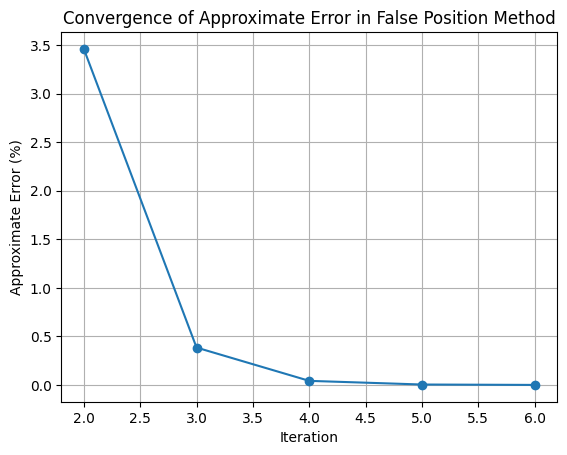


Approximate root: 59.9593174443



In [4]:
def main():
    
    tol = 0.001
    xl=40
    xu=80
    root = false_position(xl, xu, tol)
    print(f"\nApproximate root: {root:.10f}\n")

if __name__ == "__main__":
    main()